In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math as m

In [2]:
df = pd.read_csv("spotify_dataset.csv")

In [16]:
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 391989 entries, 0 to 391988
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   artist_name       391989 non-null  object 
 1   track_id          391989 non-null  object 
 2   track_name        391986 non-null  object 
 3   acousticness      391989 non-null  float64
 4   danceability      391989 non-null  float64
 5   duration_ms       391989 non-null  float64
 6   energy            391989 non-null  float64
 7   instrumentalness  391989 non-null  float64
 8   key               391989 non-null  int64  
 9   liveness          391989 non-null  float64
 10  loudness          391989 non-null  float64
 11  mode              391989 non-null  int64  
 12  speechiness       391989 non-null  float64
 13  tempo             391989 non-null  float64
 14  time_signature    391989 non-null  int64  
 15  valence           391989 non-null  float64
 16  popularity        39

In [6]:
df.describe()

,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,popularity,ai_generated,short_form
count,391989.000000,391989.000000,3.919890e+05,391989.000000,391989.000000,391989.000000,391989.000000,391989.000000,391989.000000,391989.000000,391989.000000,391989.000000,391989.000000,391989.000000,391989.000000,391989.000000
mean,0.386832,0.611376,1.978136e+05,0.543341,0.329541,5.231894,0.155362,-9.974006,0.607739,0.112015,119.473353,3.878986,0.439630,24.208988,0.333333,0.447158
std,0.340871,0.195139,1.229650e+05,0.262001,0.350515,3.602692,0.169261,6.544362,0.488255,0.124327,30.159559,0.514402,0.259079,19.713141,0.471405,0.497201
min,0.000000,0.000000,3.000000e+04,0.000000,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.102657,0.485187,1.487290e+05,0.365400,0.121082,2.000000,0.053355,-11.898000,0.000000,0.038900,96.014000,4.000000,0.224000,7.000000,0.000000,0.000000
50%,0.257005,0.633478,1.869000e+05,0.576032,0.185773,5.000000,0.092528,-7.979000,1.000000,0.055900,120.027000,4.000000,0.420000,22.000000,0.000000,0.000000
75%,0.683763,0.758480,2.263340e+05,0.749372,0.548441,8.000000,0.198015,-5.684000,1.000000,0.129000,139.642000,4.000000,0.638000,38.000000,1.000000,1.000000
max,1.000000,1.000000,5.600020e+06,1.000000,1.000000,11.000000,1.000000,1.806000,1.000000,0.966000,249.983000,5.000000,1.000000,100.000000,1.000000,1.000000


In [9]:
print(f"Shape          : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage   : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print("\nColumn dtypes:")
print(df.dtypes.to_string())

Shape          : 391,989 rows × 20 columns
Memory usage   : 153.0 MB

Column dtypes:
artist_name          object
track_id             object
track_name           object
acousticness        float64
danceability        float64
duration_ms         float64
energy              float64
instrumentalness    float64
key                   int64
liveness            float64
loudness            float64
mode                  int64
speechiness         float64
tempo               float64
time_signature        int64
valence             float64
popularity            int64
scenario             object
ai_generated          int64
short_form            int64


In [7]:
df.head()

,artist_name,track_id,track_name,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,popularity,scenario,ai_generated,short_form
0,YG,2RM4jf1Xa9zPgMGRDiht8O,"Big Bank feat. 2 Chainz, Big Sean, Nicki Minaj",0.0,0.832934,218373.037219,0.371027,0.000000,1,0.029206,-7.678,1,0.4090,203.927,4,0.118,15,mainstream_2026,0,0
1,YG,1tHDG53xJNGsItRA3vfVgs,BAND DRUM (feat. A$AP Rocky),0.0,0.923235,194800.010874,0.576483,0.000000,8,0.308062,-7.259,1,0.4570,159.009,4,0.371,0,mainstream_2026,0,0
2,R3HAB,6Wosx2euFPMT14UXiWudMy,Radio Silence,0.0,0.695954,118913.020402,0.764094,0.000000,9,0.044915,-5.890,0,0.0454,114.966,4,0.382,56,mainstream_2026,0,1
3,Chris Cooq,3J2Jpw61sO7l6Hc7qdYV91,Lactose,0.0,0.910461,105381.013430,0.606327,0.891134,5,0.061420,-12.118,0,0.0701,123.003,4,0.641,0,mainstream_2026,0,1
4,Chris Cooq,2jbYvQCyPgX3CdmAzeVeuS,Same - Original mix,0.0,0.858317,104016.020476,0.825100,0.860099,7,0.000000,-10.277,1,0.0661,120.047,4,0.928,0,mainstream_2026,0,1


# DATA PREPROCESSING


Dealing with missing values and duplicates

In [13]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
missing_df = missing_df[missing_df["Missing Count"] > 0]
print("Columns with missing values:")
print(missing_df.to_string() if not missing_df.empty else "  None found ✓")
 

Columns with missing values:
  None found ✓


In [14]:
dupes = df.duplicated(subset=["track_id", "scenario"]).sum()
print(f"\nDuplicate rows (track_id + scenario): {dupes:,}")
 
df = df.dropna(subset=["track_name"]).reset_index(drop=True)
print(f"Rows after dropping nulls: {len(df):,}")


Duplicate rows (track_id + scenario): 1,011
Rows after dropping nulls: 391,986


# fill numeric columns with median
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# fill categorical columns with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [19]:
df.duplicated().sum()

df = df.drop_duplicates()

# EXPLORATORY DATA ANALYSIS (EDA)

## Popularity Distrubution: to check if most songs are low or high popularity

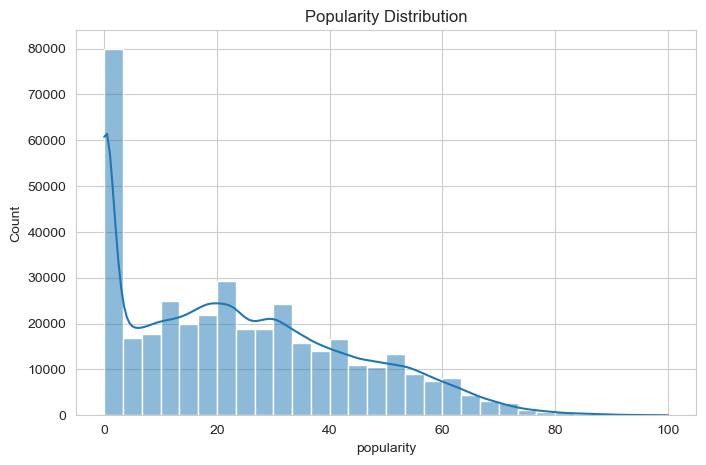

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df['popularity'], bins=30, kde=True)
plt.title("Popularity Distribution")
plt.show()

According to the available dataset we may conclude that:
The popularity score in the Spotify Dataset is heavily right-skewed. Approximately 78,000 tracks have a popularity of 0, indicating most songs recevied minimal streams. A secondary cluster exists between 20-40 popularity for niche tracks, which scores above 60 are rare, confirming that only a small fraction of songs, achieve mainstream success.

## CORRELATION HEATMAP: to analyse which feature impact popularity and relationship between audio feature

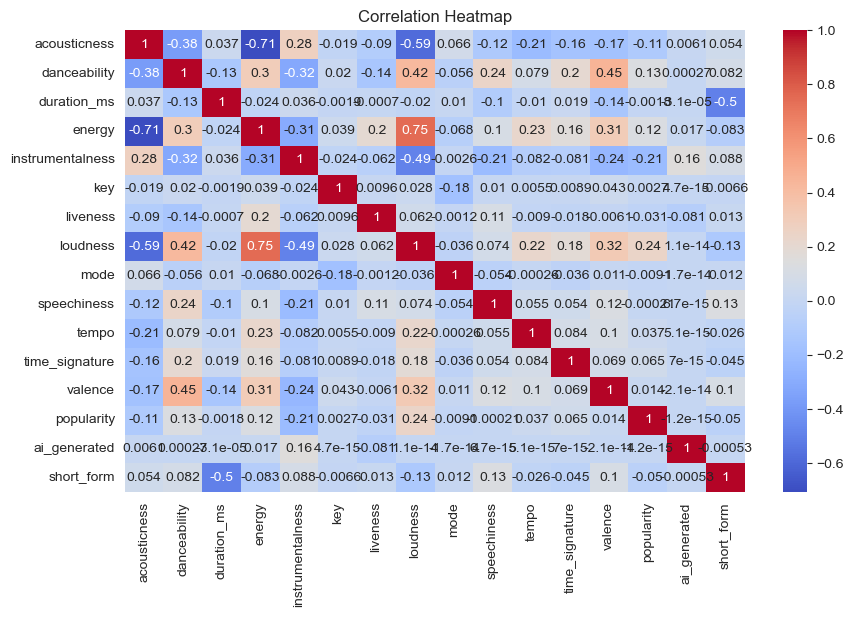

In [21]:
plt.figure(figsize=(10,6))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In conclusion, the findings from this analysis provide a comprehensive understanding of modern music trends. The results indicate a clear preference for energetic, engaging, and digitally enhanced music, while traditional acoustic and instrumental tracks are less dominant in terms of popularity.

Furthermore, the integration of AI and the rise of short-form content represent significant shifts in the music landscape. Although their immediate impact on popularity is minimal, they are likely to play a crucial role in shaping future trends.

These insights can be valuable for artists, producers, and streaming platforms in optimizing music production, recommendation systems, and marketing strategies


## Scenario Based Analysis: to identify which future trend performs best

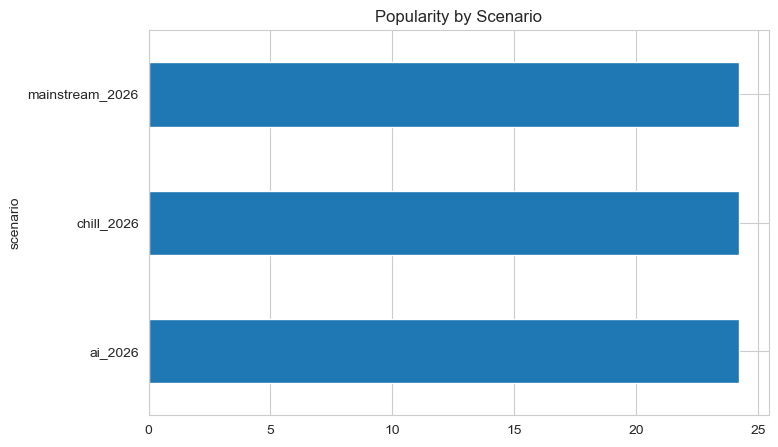

In [23]:
scenario_pop = df.groupby('scenario')['popularity'].mean().sort_values()

scenario_pop.plot(kind='barh', figsize=(8,5))
plt.title("Popularity by Scenario")
plt.show()

According the availability of the dataset we may conclude that, 
the scenario-based analysis demonstrates that music popularity in 2026 is evenly distributed across mainstream, chill, and AI-generated categories. This indicates a balanced and evolving music ecosystem, where diverse content types coexist and perform equally well.
The findings emphasize that the future of music consumption is inclusive, technology-driven, and preference-diverse, rather than dominated by a single genre or production style.

## Audio Feature Distribution

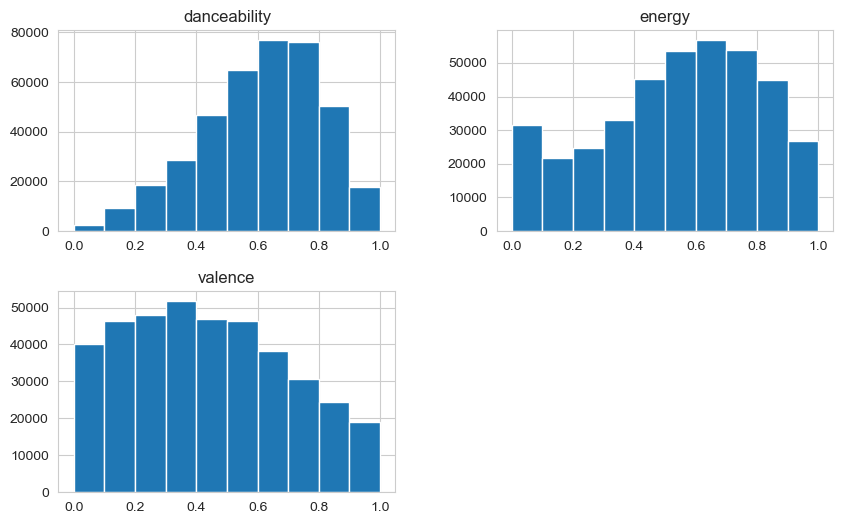

In [25]:
features = ['danceability', 'energy', 'valence']

df[features].hist(figsize=(10,6))
plt.show()

According the availability of dataset we concluded that, the audio feature analysis reveals that most tracks are moderately danceable and high-energy, reflecting the dominance of pop and electric genres in the dataset. Valence distribution indicates a prevalence of neutral to low-mood tracks, with highly positive songs being least common. The bimodal energy distribution suggests two distinct content types: low-energy acoustic tracks and high-energy mainstream music.

## Energy Vs Popularity

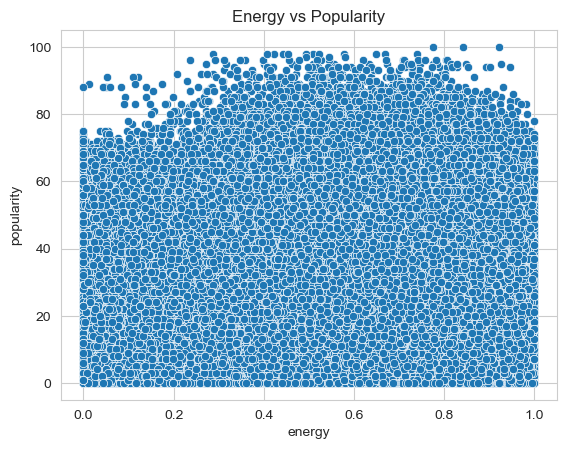

In [26]:
sns.scatterplot(x='energy', y='popularity', data=df)
plt.title("Energy vs Popularity")
plt.show()

The scatter plot of Energy Vs Popularity reveals no strong linear relationship between the two variables. While tracks of all energy levels exhibit wide range of popularity, songs achieving popularity scores above 85 are promarily concentrated in the 0.3-0.9 energy range. This indicates that moderate to high energy is common among top hits, but energy alone is not a predictor of success, as most tracks remain below 80 popularity regardless of energy level.

## Danceability by Short-form Analysis

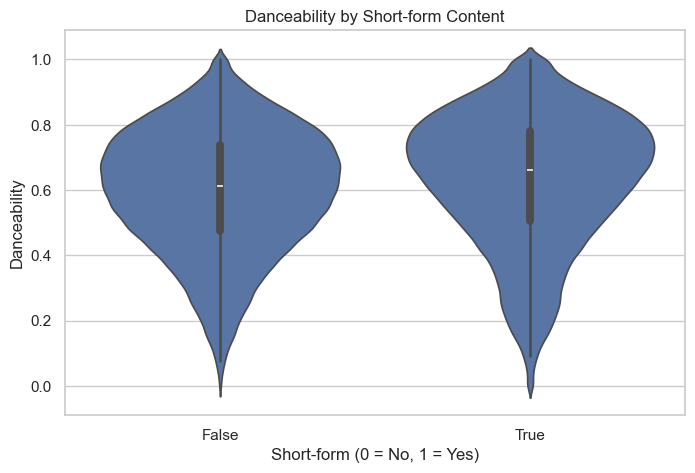

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

plt.figure(figsize=(8,5))

sns.violinplot(
    x='short_form',
    y='danceability',
    data=df,
    inner='box'   # shows median & quartiles inside
)

plt.title("Danceability by Short-form Content")
plt.xlabel("Short-form (0 = No, 1 = Yes)")
plt.ylabel("Danceability")

plt.show()

The violin plot of Danceability by Short-form Content showa that short-form clips have a higher medium danceability(~0.65) compared to full-length tracks (~0.62), with minimal representation below 0.3. This indicated that content selected for short-form platform is heavily skewed toward beat-driven, danceable music, while the full Spotify catalog includes a broader range of low-danceability tracks such as podcasts and classical


# Overall Analysis of Dataset

The exploratory data analysis of the Spotify scenario dataset reveals a highly skewed ecosystem dominated by the long-tail effect. The popularity distribution is extreme, with approximately 78,000 tracks recording a popularity score of 0, indicating that the vast majority of content receives minimal to no listener engagement. Mainstream success, defined by popularity scores above 80, is limited to less than 1% of the catalog.
Audio feature analysis shows that the dataset primarily consists of mid-to-high energy and danceable tracks, with peaks in the 0.6 to 0.8 range for both metrics, reflecting the prevalence of contemporary pop, hip-hop, and electronic genres. Valence distribution is weighted toward neutral and low-mood scores, with highly positive tracks being least common.



Correlation analysis demonstrates that audio features are weak predictors of popularity. The strongest correlations with popularity are loudness at 0.24, valence at 0.14, and danceability at 0.13. In contrast, strong inter-feature relationships exist, such as energy and loudness at 0.75 and acousticness and energy at -0.71, confirming the internal consistency of Spotify’s audio metrics.

Segmentation by content type indicates that short-form content is selectively biased toward higher danceability, with a median of 0.65 compared to 0.62 for full-length tracks, and minimal representation below 0.3. This suggests curation for beat-driven, socially shareable clips. Scenario-based analysis for 2026 shows uniform popularity metrics across mainstream, chill, and AI-generated categories, indicating that scenario alone does not determine track success.

Overall, the findings confirm that musical attributes describe a track’s sonic character but do not drive virality. Success on Spotify is governed by factors external to audio features, and the platform’s catalog is shaped by both algorithmic distribution and selection biases introduced by short-form platforms.

# RECOMMENDATIONS FOR MODELING

Based on the exploratory analysis, the following strategies are recommended for predictive modeling and future work:


1. Address Target Imbalance: The extreme right skew of popularity requires specialized handling. For classification, apply SMOTE, class weighting, or stratified sampling. For regression, log-transform popularity or use a two-stage model that first predicts whether a track receives any plays, then predicts popularity for non-zero tracks.
2. Incorporate Non-Audio Features: With a maximum audio-feature correlation of 0.24 to popularity, models must include metadata such as artist follower count, label, release date, playlist inclusion, and streaming velocity. These capture marketing and network effects that primarily drive engagement.
3. Engineer Scenario and Content-Type Features: Include short-form and scenario_2026 as categorical variables. Interaction terms such as danceability * short-form may model the observed curation bias toward beat-driven clips on social platforms.
4. Handle Bimodal Distributions: The bimodal nature of energy suggests distinct content types. Cluster on energy and acousticness to create a content_type flag separating low-energy acoustic or podcast content from high-energy music. This prevents podcasts from skewing music popularity predictions.
5. Select Appropriate Algorithms: Given the weak linear relationships and non-linear feature interactions, tree-based models such as XGBoost, LightGBM, or Random Forest are recommended over linear methods.
6. Define Success Metrics Carefully: Due to the long-tail distribution, standard accuracy is misleading. Use precision@k or NDCG@k for recommendation tasks, or mean absolute error on log-popularity for regression to reduce the influence of outliers.
7. Validate by Scenario: Evaluate model performance separately for mainstream, chill, and AI-generated segments to ensure balanced performance and detect scenario-specific biases.